# Electronic Nose Project
## Beef Quality Classification
(c)2024 Djoko Purwanto, Dept. of Electrical Engineering <br>
Institut Teknologi Sepuluh Nopember (ITS) <br>
djoko@its.ac.id

In [1]:
student_name = 'Muhammad Zahran Razzaq'       # Write your name here
print(f'Hello {student_name} !')

Hello Muhammad Zahran Razzaq !


In [2]:
import platform
import psutil
import tensorflow as tf
from datetime import datetime

def get_system_info():
    info = {}   
    # Get system information
    info['platform'] = platform.system()
    info['platform-version'] = platform.version()
    info['architecture'] = platform.machine()
    info['hostname'] = platform.node()
    info['processor'] = platform.processor()
    info['ram'] = str(round(psutil.virtual_memory().total / (1024.0 **3))) + ' GB'    
    return info

print(f'Program start ...')
# Print the system information
system_info = get_system_info()
for key, value in system_info.items():
    print(f'{key}: {value}')

# Print TensorFlow version
print(f'TensorFlow version: {tf.__version__}')
if tf.config.list_physical_devices('GPU'):
    print(f'GPU is being used by TensorFlow')
else: print(f'GPU is unavailable for TensorFlow')

# Get the current time
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
# Print the current time
print(f'The current time is: {current_time}')

Program start ...
platform: Windows
platform-version: 10.0.26200
architecture: AMD64
hostname: LAPTOP-9NNH1THV
processor: Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
ram: 20 GB
TensorFlow version: 2.21.0
GPU is unavailable for TensorFlow
The current time is: 2026-09-28 10:28:32


### (1) Read and Visualize Data

In [3]:
import pandas as pd

df_sheet = pd.read_excel('e-nose_dataset_12_beef_cuts.xlsx', sheet_name='2.Round') 
df_sheet

,Minute,TVC,Label,MQ135,MQ136,MQ137,MQ138,MQ2,MQ3,MQ4,MQ5,MQ6,MQ8,MQ9
0,1,1.875890,1,14.87,37.65,5.16,20.37,12.25,16.24,28.66,6.11,3.59,46.19,10.01
1,2,1.875890,1,14.94,38.56,5.09,20.46,13.37,16.38,28.50,5.74,3.39,46.19,10.05
2,3,1.875890,1,15.00,39.50,5.07,20.46,12.40,17.01,28.18,6.18,3.25,46.83,10.21
3,4,1.875890,1,14.87,40.48,5.05,20.37,12.50,16.44,28.18,5.60,3.16,46.19,10.13
4,5,1.875890,1,14.87,40.73,5.00,20.27,12.01,16.38,28.50,5.48,3.11,47.48,10.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2215,2216,5.758033,4,11.48,3.15,27.25,13.06,10.97,8.70,3.01,17.67,34.93,33.36,8.97
2216,2217,5.758033,4,11.35,3.12,27.53,12.90,10.93,8.53,2.96,16.93,34.47,33.55,8.97
2217,2218,5.758033,4,11.26,3.14,27.67,12.90,10.68,8.63,2.96,17.00,36.62,37.90,9.01
2218,2219,5.758033,4,11.35,3.12,27.39,12.90,10.35,8.60,2.95,17.14,34.70,34.51,9.04


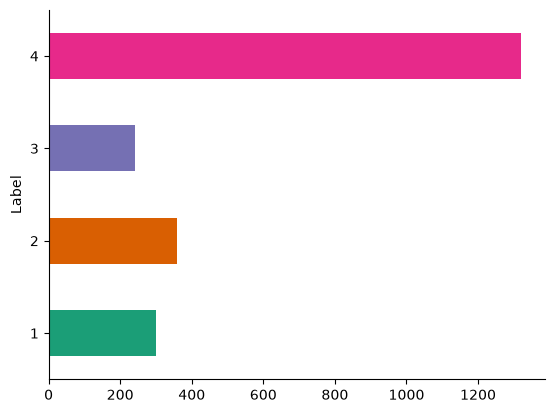

In [5]:
from matplotlib import pyplot as plt
import seaborn as sns

df_sheet.groupby('Label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

### (2) Create Dataset

In [6]:
df_dataset = df_sheet.copy()

encode_data = pd.get_dummies(df_dataset.Label)
df_dataset = pd.concat([df_dataset, encode_data], axis=1)

df_dataset.drop(columns=['Minute', 'TVC','Label'], inplace=True)
df_dataset

,MQ135,MQ136,MQ137,MQ138,MQ2,MQ3,MQ4,MQ5,MQ6,MQ8,MQ9,1,2,3,4
0,14.87,37.65,5.16,20.37,12.25,16.24,28.66,6.11,3.59,46.19,10.01,True,False,False,False
1,14.94,38.56,5.09,20.46,13.37,16.38,28.50,5.74,3.39,46.19,10.05,True,False,False,False
2,15.00,39.50,5.07,20.46,12.40,17.01,28.18,6.18,3.25,46.83,10.21,True,False,False,False
3,14.87,40.48,5.05,20.37,12.50,16.44,28.18,5.60,3.16,46.19,10.13,True,False,False,False
4,14.87,40.73,5.00,20.27,12.01,16.38,28.50,5.48,3.11,47.48,10.13,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2215,11.48,3.15,27.25,13.06,10.97,8.70,3.01,17.67,34.93,33.36,8.97,False,False,False,True
2216,11.35,3.12,27.53,12.90,10.93,8.53,2.96,16.93,34.47,33.55,8.97,False,False,False,True
2217,11.26,3.14,27.67,12.90,10.68,8.63,2.96,17.00,36.62,37.90,9.01,False,False,False,True
2218,11.35,3.12,27.39,12.90,10.35,8.60,2.95,17.14,34.70,34.51,9.04,False,False,False,True


In [7]:
import numpy as np

ds_values = df_dataset.values

ds_inputs = ds_values[:,0:11]
ds_outputs = ds_values[:,11:]

print(f'input shape  : {ds_inputs.shape}')
print(f'output shape : {ds_outputs.shape}')
print(ds_inputs[0:5,:])
print(ds_outputs[0:5,:])

input shape  : (2220, 11)
output shape : (2220, 4)
[[14.87 37.65 5.16 20.37 12.25 16.24 28.66 6.11 3.59 46.19 10.01]
 [14.94 38.56 5.09 20.46 13.37 16.38 28.5 5.74 3.39 46.19 10.05]
 [15.0 39.5 5.07 20.46 12.4 17.01 28.18 6.18 3.25 46.83 10.21]
 [14.87 40.48 5.05 20.37 12.5 16.44 28.18 5.6 3.16 46.19 10.13]
 [14.87 40.73 5.0 20.27 12.01 16.38 28.5 5.48 3.11 47.48 10.13]]
[[True False False False]
 [True False False False]
 [True False False False]
 [True False False False]
 [True False False False]]


#### Input normalization

In [8]:
inp_min = np.min(ds_inputs); inp_max = np.max(ds_inputs)
print(f'input --> min = {inp_min}; max = {inp_max}')

input --> min = 2.4; max = 54.08


Set new input min and input max, then do input normalization

In [9]:
def normalization(x,xmin,xmax):
    return 2*(x-xmin)/(xmax-xmin) - 1

inp_min, inp_max = 0.0, 60.0
ds_inputs_norm = normalization(ds_inputs, inp_min, inp_max)

print(f'input normalization shape: {ds_inputs_norm.shape}')
print(ds_inputs_norm[0:5,:])

input normalization shape: (2220, 11)
[[-0.5043333333333333 0.2549999999999999 -0.828 -0.32099999999999995
  -0.5916666666666667 -0.45866666666666667 -0.04466666666666663
  -0.7963333333333333 -0.8803333333333333 0.5396666666666665
  -0.6663333333333333]
 [-0.502 0.28533333333333344 -0.8303333333333334 -0.31799999999999995
  -0.5543333333333333 -0.45400000000000007 -0.050000000000000044
  -0.8086666666666666 -0.887 0.5396666666666665 -0.665]
 [-0.5 0.31666666666666665 -0.831 -0.31799999999999995
  -0.5866666666666667 -0.43299999999999994 -0.06066666666666665 -0.794
  -0.8916666666666666 0.5609999999999999 -0.6596666666666666]
 [-0.5043333333333333 0.3493333333333333 -0.8316666666666667
  -0.32099999999999995 -0.5833333333333333 -0.45199999999999996
  -0.06066666666666665 -0.8133333333333334 -0.8946666666666667
  0.5396666666666665 -0.6623333333333333]
 [-0.5043333333333333 0.3576666666666666 -0.8333333333333334
  -0.32433333333333336 -0.5996666666666667 -0.45400000000000007
  -0.050000

#### Split dataset into 80% train and 20% test set

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(ds_inputs_norm, ds_outputs, test_size=0.2, random_state=42)

print(f'Train set --> input shape: {X_train.shape}, output shape: {Y_train.shape}')
print(f'Test set  --> input shape: {X_test.shape}, output shape: {Y_test.shape}')

Train set --> input shape: (1776, 11), output shape: (1776, 4)
Test set  --> input shape: (444, 11), output shape: (444, 4)


### (3) Build Model

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(20, activation='sigmoid', input_dim=X_train.shape[1]),
    tf.keras.layers.Dense(4, activation='softmax') ])

model.summary()
print('Model created')

c:\Users\Zahran\miniconda3\envs\dsec\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324 (1.27 KB)

 Trainable params: 324 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

Model created


### (4) Train model

In [13]:
import time
import datetime

epochs = 5000
batch_size = int(0.1*len(X_train))
print('Batch size: ',batch_size)

X_train_tensor = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)
Y_train_tensor = tf.convert_to_tensor(Y_train, dtype=tf.int32)
Y_test_tensor = tf.convert_to_tensor(Y_test, dtype=tf.int32)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.1, patience=50, min_lr=1e-6)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='accuracy', patience=75, restore_best_weights=True)

optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-2)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

starttime = time.time()

model_history = model.fit(X_train_tensor,Y_train_tensor, epochs=epochs,
    validation_data=(X_test_tensor, Y_test_tensor), verbose=2, batch_size=batch_size,
    callbacks=[reduce_lr, early_stopping] )

stoptime =  time.time()-starttime
trainingtime = datetime.timedelta(seconds=stoptime)
print(f'\nTraining time : {trainingtime}')
print(f'End of training')

Batch size:  177
Epoch 1/5000
11/11 - 1s - 85ms/step - accuracy: 0.3164 - loss: 1.4697 - val_accuracy: 0.5833 - val_loss: 1.1437 - learning_rate: 0.0100
Epoch 2/5000
11/11 - 0s - 11ms/step - accuracy: 0.5974 - loss: 1.1046 - val_accuracy: 0.5833 - val_loss: 1.0782 - learning_rate: 0.0100
Epoch 3/5000
11/11 - 0s - 9ms/step - accuracy: 0.5974 - loss: 1.0306 - val_accuracy: 0.5833 - val_loss: 0.9683 - learning_rate: 0.0100
Epoch 4/5000
11/11 - 0s - 9ms/step - accuracy: 0.5974 - loss: 0.9374 - val_accuracy: 0.5833 - val_loss: 0.8910 - learning_rate: 0.0100
Epoch 5/5000
11/11 - 0s - 9ms/step - accuracy: 0.5985 - loss: 0.8475 - val_accuracy: 0.6216 - val_loss: 0.7802 - learning_rate: 0.0100
Epoch 6/5000
11/11 - 0s - 8ms/step - accuracy: 0.6729 - loss: 0.7490 - val_accuracy: 0.7027 - val_loss: 0.6816 - learning_rate: 0.0100
Epoch 7/5000
11/11 - 0s - 10ms/step - accuracy: 0.7264 - loss: 0.6645 - val_accuracy: 0.8468 - val_loss: 0.6025 - learning_rate: 0.0100
Epoch 8/5000
11/11 - 0s - 9ms/step 

### (5) Performance Evaluation
#### Training

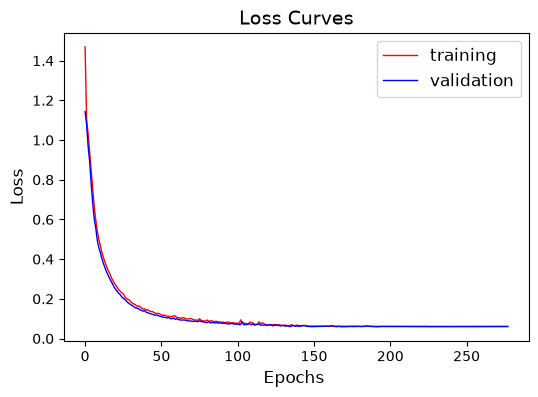

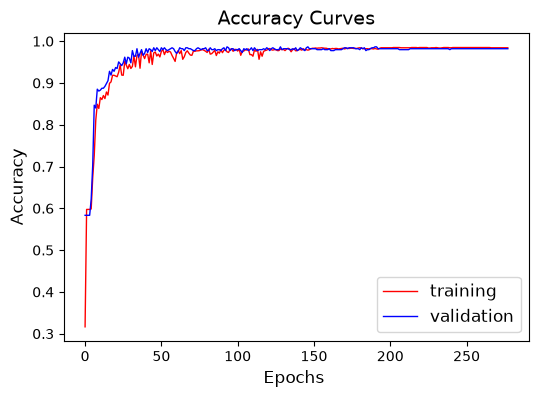

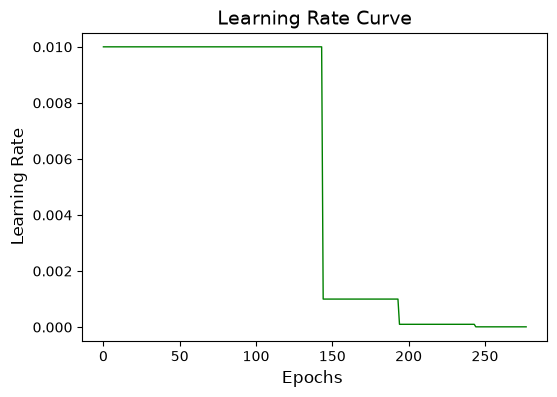

In [14]:
plt.figure(figsize=[6, 4])
plt.plot(model_history.history['loss'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_loss'], 'b', linewidth=1.0)
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs ', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss Curves', fontsize=14)
plt.show()

plt.figure(figsize=[6, 4])
plt.plot(model_history.history['accuracy'], 'r', linewidth=1.0)
plt.plot(model_history.history['val_accuracy'], 'b', linewidth=1.0)
plt.legend(['training', 'validation'], fontsize=12)
plt.xlabel('Epochs ', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy Curves', fontsize=14)
plt.show()

plt.figure(figsize=[6, 4])
plt.plot(model_history.history['learning_rate'], 'g', linewidth=1.0)
plt.xlabel('Epochs ', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Curve', fontsize=14)
plt.show()

#### Confusion Matrix

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


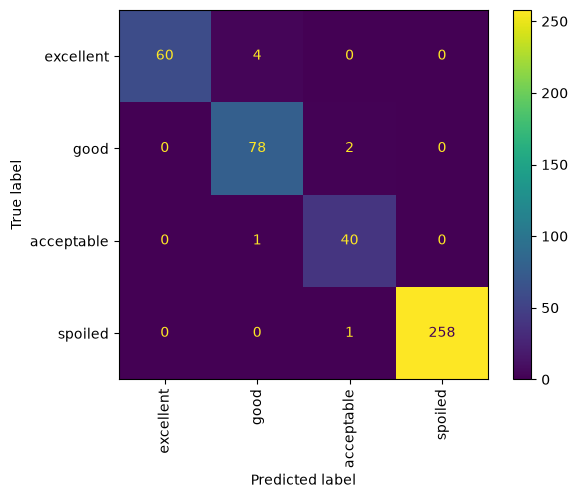

In [15]:
from sklearn import metrics

output_label =['excellent','good','acceptable','spoiled']
pred_test_encode = model.predict(X_test_tensor)

pred_test = np.argmax(pred_test_encode,axis=1)
out_test = np.argmax(Y_test,axis=1)

cm_test = metrics.confusion_matrix(out_test, pred_test)
cm__test_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix = cm_test, display_labels = output_label)
cm__test_display.plot(xticks_rotation='vertical')
plt.show()

#### Precision, Recall, F1 Score

In [16]:
print(metrics.classification_report(out_test, pred_test, target_names=output_label))

              precision    recall  f1-score   support

   excellent       1.00      0.94      0.97        64
        good       0.94      0.97      0.96        80
  acceptable       0.93      0.98      0.95        41
     spoiled       1.00      1.00      1.00       259

    accuracy                           0.98       444
   macro avg       0.97      0.97      0.97       444
weighted avg       0.98      0.98      0.98       444



### (6) Explore the Model
Model weights and biases

In [17]:
dense_layer1 = model.layers[0]
weights1, biases1 = dense_layer1.get_weights()
print(f'Weights_1 shape: {weights1.shape}')
print(f'Biases_1 shape: {biases1.shape}')
print(f'Weights_1:\n {weights1}')
print(f'Biases_1 :\n {biases1}')

dense_layer2 = model.layers[1]
weights2, biases2 = dense_layer2.get_weights()
print(f'Weights_2 shape: {weights2.shape}')
print(f'Biases_2 shape: {biases2.shape}')
print(f'Weights_2:\n {weights2}')
print(f'Biases_2 :\n {biases2}')

Weights_1 shape: (11, 20)
Biases_1 shape: (20,)
Weights_1:
 [[-0.49673086 -0.19195022 -0.32001507 -0.02858155  0.43984812  0.7789703
   0.10870647  0.20640269 -0.50477105 -0.09112339 -0.10905071 -0.27004254
  -0.5669689  -0.5384777   0.5710091  -0.5055324  -0.07681112 -0.75858945
  -1.2053697   0.5184446 ]
 [-2.159873    0.9675849  -0.17105617  0.7557967   1.9412398   2.6548524
   3.2615018   1.8746587  -2.7193701  -1.3836765   2.583726   -3.0332994
  -4.7570004  -3.4170406   1.5769895  -1.6546324  -1.9762548  -4.0742784
  -2.2264628   1.2199585 ]
 [ 2.5584323  -0.20999661  1.0494083  -3.3146284  -3.9575155  -1.1941131
  -2.7277877  -4.0410614   2.0802305   2.7255602  -3.4347076   3.1309986
   1.1041434   3.7084694  -5.0869036   4.0414963   4.377557    0.37169775
   1.4106237  -3.5813832 ]
 [ 0.04895907  1.1626585   0.25084272  0.40738976  0.36152768  1.276067
   0.4637997   0.11617278 -0.42619213 -0.2756778  -0.04402969 -0.26059878
  -1.8352346   0.19262609  0.40768546 -0.09978434 -0.

Save the model

In [18]:
model_filename = 'BQCmodelSoftmaxTF'+tf.__version__+'.keras'

model.save(model_filename)
print(f'Model saved as {model_filename}')

print(f'End of program... ')

Model saved as BQCmodelSoftmaxTF2.21.0.keras
End of program... 


In [ ]:
# Input sensor baru untuk klasifikasi kualitas daging
import os
import numpy as np
import tensorflow as tf

sensor_names = [
    'MQ135', 'MQ136', 'MQ137', 'MQ138', 'MQ2', 'MQ3',
    'MQ4', 'MQ5', 'MQ6', 'MQ8', 'MQ9'
 ]

# Masukkan nilai sensor dengan pemisah desimal titik atau koma.
sensor_values_text = '17,85 15,58 7,95 21,23 16,52 24,07 12,29 9,02 14,26 40,29 14,4'
sensor_values = [float(value.replace(',', '.')) for value in sensor_values_text.split()]

if len(sensor_values) != len(sensor_names):
    raise ValueError(f'Dibutuhkan {len(sensor_names)} nilai sensor, tetapi diterima {len(sensor_values)}.')

sensor_data = np.asarray(sensor_values, dtype=np.float32).reshape(1, -1)
sensor_data_norm = 2 * (sensor_data - 0.0) / (60.0 - 0.0) - 1

model_filename = 'BQCmodelSoftmaxTF' + tf.__version__ + '.keras'
if 'model' not in globals():
    if not os.path.exists(model_filename):
        raise FileNotFoundError(f'Model tidak ditemukan: {model_filename}')
    model = tf.keras.models.load_model(model_filename)

# PENTING: kolom `Label` pada dataset berupa INTEGER 1..4, sehingga
# pd.get_dummies() menghasilkan kolom [1, 2, 3, 4] (urut NAIK, bukan alfabetis).
# Indeks kelas karena itu sama dengan Label-1:
#   0 -> Label 1 = excellent, 1 -> Label 2 = good,
#   2 -> Label 3 = acceptable, 3 -> Label 4 = spoiled
LABEL_TO_NAME = {1: 'excellent', 2: 'good', 3: 'acceptable', 4: 'spoiled'}
class_names = [LABEL_TO_NAME[int(c)] for c in
               (list(encode_data.columns) if 'encode_data' in globals() else [1, 2, 3, 4])]

# Periksa konsistensi bila sel ini dijalankan setelah sel pembuatan dataset.
assert class_names == ['excellent', 'good', 'acceptable', 'spoiled'], (
    f'urutan kelas tidak sesuai: {class_names}')

class_probabilities = model.predict(sensor_data_norm, verbose=0)[0]
predicted_index = int(np.argmax(class_probabilities))
predicted_quality = class_names[predicted_index]

print('Nilai sensor:')
for name, value in zip(sensor_names, sensor_values):
    print(f'  {name}: {value}')
print(f'\nKualitas daging: {predicted_quality}')
print(f'Indeks kelas terprediksi: {predicted_index} (Label {predicted_index + 1})')
print('\nProbabilitas setiap kelas:')
for class_name, probability in zip(class_names, class_probabilities):
    print(f'  {class_name}: {probability:.4f}')


---
### (7) Catatan penting & lanjutan ke implementasi Arduino

**Perbaikan pada sel di atas.** Sel prediksi ini sebelumnya memakai fallback
`['acceptable', 'excellent', 'good', 'spoiled']` dengan asumsi `pd.get_dummies`
mengurutkan kelas secara alfabetis. Asumsi itu **tidak berlaku** di sini karena kolom
`Label` bertipe *integer* 1..4, sehingga `get_dummies` menghasilkan kolom `[1, 2, 3, 4]`
(urut naik). Akibatnya, bila sel dijalankan pada kernel baru (tanpa `encode_data`),
indeks 0 akan diberi nama `acceptable` padahal seharusnya `excellent` — semua label
bergeser. Pemetaan yang benar: `1=excellent, 2=good, 3=acceptable, 4=spoiled`.

**Batasan notebook ini untuk tugas akhir.** Notebook ini hanya melatih dari sheet
`2.Round` (2.220 baris) dengan penskalaan global `0..60`. Model tersebut mencapai
98,42% pada sheet asalnya, tetapi turun drastis menjadi **37,43%** bila diuji pada
gabungan 12 potongan daging (26.640 baris) — artinya tidak memenuhi langkah
*Integrasi Data* pada soal.

**Pipeline lengkap** (12 sheet digabung, min-max per fitur, pencarian arsitektur,
ekstraksi bobot ke header C++) tersedia sebagai skrip yang dapat dijalankan ulang:

```bash
python training/train_bqc.py     # latih + evaluasi + ekspor nn_params.h
bash   arduino/test/run_checks.sh  # verifikasi kode Arduino vs model Python
```

Dokumentasi lengkap ada di `docs/LAPORAN.md`, sketch Arduino di
`arduino/BQC_Arduino_Mega/BQC_Arduino_Mega.ino`.
